# Virtual Niche Analysis

This notebook performs **counterfactual perturbation analysis** using a trained VirtNiche model.

The central question is:

> **How does changing the perturbation state of a target cell alter its predicted transcriptional state when cell identity and the spatial microenvironment are held fixed?**

For each comparison, we keep the following quantities unchanged:

- central cell type,
- neighboring cell types,
- neighboring perturbation states,


Only the **central-cell perturbation** is changed.

For gene \(g\), perturbation \(P\), control perturbation \(P_0\), central cell type \(C\), and fixed environment \(E\), we compare

$
\hat{x}_g(P, C, E)
$

against

$
\hat{x}_g(P_0, C, E).
$

This provides a model-based counterfactual estimate of the perturbation response under a controlled spatial niche.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import torch

print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 3090


/home/sirm/software/miniconda3/envs/VirtNiche/lib/python3.9/site-packages/torch/cuda/__init__.py:546: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


## 1. Setup

After running VirtNiche_train.ipynb, the trained model will be saved to ./VirtNiche_Perturb_FISH_test_model/. Alternatively, you can download our pretrained model from the Zenodo link (10.5281/zenodo.22760559) and place it in this directory. 

In [ ]:
import sys
import re
import warnings
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import scanpy as sc

warnings.simplefilter("ignore", UserWarning)

sys.path.insert(0, str(Path("..").resolve()))

import VirtNiche
from VirtNiche._utils import compute_spatial_neighbors

Global seed set to 0
/home/sirm/software/miniconda3/envs/VirtNiche/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
adata_path = "./Perturb-FISH-rawadata/Measured_annotated_splited.h5ad"

result_name = "Perturb_FISH_test"
model_dir = f"./VirtNiche_{result_name}_model/"

k_neighbors = 6

ordered_keys = ["perturb_gene"]
categorical_keys = ["cell_type"]

## 2. Load data and trained model



In [4]:
adata = sc.read(adata_path)

neighbors_index = compute_spatial_neighbors(
    adata,
    n_neighbors=k_neighbors,
    spatial_key="spatial",
)

VirtNiche.VirtNiche.setup_anndata(
    adata,
    ordered_attributes_keys=ordered_keys,
    categorical_attributes_keys=categorical_keys,
)

model = VirtNiche.VirtNiche.load(
    model_dir,
    adata=adata,
)

adata

INFO     Generating sequential column names                                                                        
INFO     File ./VirtNiche_Perturb_FISH_test_model/model.pt already downloaded                                      


Global seed set to 42


AnnData object with n_obs × n_vars = 120594 × 500
    obs: 'area_of_the_cell_in_pixels', 'gRNA', 'perturb', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden', 'manual', 'cell_type', 'perturb_celltype_key', 'microenv_key', 'celltype_microenv_key', 'niche_key', 'split', '_indices', '_scvi_cell_type'
    var: 'id', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'perturb_gene', 'spatial'

## 3. Perturbation representations

Each perturbation is associated with a precomputed embedding stored in `adata.obsm["perturb_gene"]`.

Alternatively, you can use the perturbation embedding file ./CellHermes-Embedding/CellHermes_embbding_Perturb-FISH.pkl. It contains the same perturbation representations used in adata.obsm["perturb_gene"].

In [6]:
perturb_labels = adata.obs["perturb"].to_numpy()

perturb_gene_vectors = {}

for perturb in pd.unique(perturb_labels):
    first_idx = np.flatnonzero(perturb_labels == perturb)[0]
    perturb_gene_vectors[perturb] = np.asarray(
        adata.obsm["perturb_gene"][first_idx],
        dtype=np.float32,
    )

len(perturb_gene_vectors)

37

## 4. Utilities


In [ ]:
def _get_perturbation_vector(label, table):
    """Return the embedding associated with a perturbation label."""
    if label in table:
        return np.asarray(table[label], dtype=np.float32)

    aliases = {
        "None": [None, "none", "NONE", "Unperturbed", "unperturbed"],
        "Control": ["control", "CTRL", "ctrl"],
    }

    for alias in aliases.get(label, []):
        if alias in table:
            return np.asarray(table[alias], dtype=np.float32)

    raise KeyError(
        f"Missing perturbation embedding for '{label}'. "
        f"Example keys: {list(table)[:20]}"
    )

In [ ]:
def _parse_environment(env_spec, K=None):
    """Expand an environment specification into perturbation and cell-type lists."""
    items = [
        item.strip()
        for item in env_spec.split(";")
        if item.strip()
    ]

    neighbor_perturbs = []
    neighbor_cell_types = []

    pattern = re.compile(
        r"^(?P<perturb>[^|]+)\|(?P<cell_type>[^:]+):(?P<count>\d+)$"
    )

    for item in items:
        match = pattern.match(item)

        if match is None:
            raise ValueError(
                f"Invalid environment item: '{item}'. "
                "Expected 'Perturbation|CellType:Count'."
            )

        perturb = match.group("perturb").strip()
        cell_type = match.group("cell_type").strip()
        count = int(match.group("count"))

        if count <= 0:
            continue

        neighbor_perturbs.extend([perturb] * count)
        neighbor_cell_types.extend([cell_type] * count)

    if K is not None and len(neighbor_cell_types) != K:
        raise ValueError(
            f"Environment contains {len(neighbor_cell_types)} neighbors, "
            f"but K={K}."
        )

    return neighbor_perturbs, neighbor_cell_types

In [ ]:

def predict_virtual_niche(
    model,
    neighbors_index,
    perturb_gene_vectors,
    center_perturb,
    center_cell_type,
    env_spec,
    K,
    genes=None,
    reference_index=0,
    use_global_unknown_mean=True,
):
    """
    Predict expression for a counterfactual central cell in a user-defined niche.

    The reference index is used only to supply the library-size context required
    by the prediction interface.
    """
    if not 0 <= reference_index < len(neighbors_index):
        raise IndexError(
            f"reference_index={reference_index} is outside the valid range."
        )

    neighbor_perturbs, neighbor_cell_types = _parse_environment(
        env_spec,
        K=K,
    )

    center_sample_indices = np.array([reference_index], dtype=int)
    neighbors_sample_indices = neighbors_index[reference_index][None, :]

    if neighbors_sample_indices.shape[1] != K:
        raise ValueError(
            f"K mismatch: virtual niche uses K={K}, but neighbors_index "
            f"contains {neighbors_sample_indices.shape[1]} neighbors."
        )

    center_vector = _get_perturbation_vector(
        center_perturb,
        perturb_gene_vectors,
    )

    neighbor_vectors = np.stack(
        [
            _get_perturbation_vector(perturb, perturb_gene_vectors)
            for perturb in neighbor_perturbs
        ],
        axis=0,
    ).astype(np.float32)

    means, _ = model.predict_custom_niche(
        center_sample_indices=center_sample_indices,
        neighbors_sample_indices=neighbors_sample_indices,
        center_categorical_attributes={
            "cell_type": np.array([center_cell_type], dtype=object),
        },
        center_ordered_attributes={
            "perturb_gene": center_vector[None, :],
        },
        neighbor_categorical_attributes={
            "cell_type": np.asarray(
                neighbor_cell_types,
                dtype=object,
            )[None, :],
        },
        neighbor_ordered_attributes={
            "perturb_gene": neighbor_vectors[None, :, :],
        },
        use_global_unknown_mean=use_global_unknown_mean,
    )

    if hasattr(means, "detach"):
        means = means.detach().cpu().numpy()
    else:
        means = np.asarray(means)

    var_names = model.adata.var_names

    if genes is None:
        return pd.Series(
            means[0],
            index=var_names,
            name="pred_expr",
        )

    missing_genes = [
        gene
        for gene in genes
        if gene not in var_names
    ]

    if missing_genes:
        raise KeyError(
            f"Genes not found in model.adata.var_names: {missing_genes}"
        )

    gene_idx = [
        var_names.get_loc(gene)
        for gene in genes
    ]

    return pd.Series(
        means[0, gene_idx],
        index=genes,
        name="pred_expr",
    )

## 5. Demo: Predicting expression in a virtual niche

VirtNiche allows us to define a virtual spatial niche by specifying:

1. the perturbation and cell type of the **central cell**;
2. the perturbation and cell type composition of its **neighboring cells**.

We first define how a spatial environment is represented, then inspect how it is parsed, and finally use it to predict the gene-expression profile of the central cell.

### 5.1 Define a virtual microenvironment

Each neighboring population is represented as:

`Perturbation|CellType:Count`

Multiple populations are separated by semicolons:

`Perturbation|CellType:Count;Perturbation|CellType:Count;...`

For example,

`Control|Tumor:4;Control|T_cell:2`

defines a six-cell neighborhood consisting of:

| Perturbation | Cell type | Number of neighbors |
|---|---|---:|
| Control | Tumor | 4 |
| Control | T_cell | 2 |

In this demo, we place a `MAP3K7`-perturbed tumor cell at the center of this virtual microenvironment.

In [13]:
K = 6

center_perturb = "MAP3K7"
center_cell_type = "Tumor"

env_spec = "Control|Tumor:4;Control|T_cell:2"

print("Central cell:")
print(f"  {center_perturb}|{center_cell_type}")

print("\nMicroenvironment:")
print(f"  {env_spec}")

Central cell:
  MAP3K7|Tumor

Microenvironment:
  Control|Tumor:4;Control|T_cell:2


### 5.2 Parse the microenvironment

The compact microenvironment specification is expanded into one perturbation label and one cell-type label for each of the \(K\) neighboring cells.

This is handled internally by `_parse_environment()`.

In [14]:
neighbor_perturbs, neighbor_cell_types = _parse_environment(
    env_spec,
    K=K,
)

neighbor_perturbs

['Control', 'Control', 'Control', 'Control', 'Control', 'Control']

In [15]:
neighbor_cell_types

['Tumor', 'Tumor', 'Tumor', 'Tumor', 'T_cell', 'T_cell']

### 5.3 Predict the expression profile of the central cell

We can now predict the transcriptional state of the central `MAP3K7|Tumor` cell under the specified virtual microenvironment.

The `reference_index` is used only to provide the library-size reference required by the prediction interface. The perturbation state, cell type, and microenvironment are defined explicitly by the virtual niche.

In [16]:
reference_index = 3

pred_expr = predict_virtual_niche(
    model=model,
    neighbors_index=neighbors_index,
    perturb_gene_vectors=perturb_gene_vectors,
    center_perturb=center_perturb,
    center_cell_type=center_cell_type,
    env_spec=env_spec,
    K=K,
    genes=None,
    reference_index=reference_index,
)

pred_expr

name
PDK4       0.170155
CCL26      0.025595
CX3CL1     0.036030
PGLYRP1    0.054248
CD4        0.047966
             ...   
ATM        0.143697
PRF1       0.095234
IL10       0.054301
IL17A      0.058839
NOTCH1     0.510831
Name: pred_expr, Length: 500, dtype: float32

Conceptually, this prediction can be written as

$\hat{\mathbf{x}}=f_{\theta}\left(\text{MAP3K7},\text{Tumor},4\times(\text{Control},\text{Tumor})+2\times(\text{Control},\text{T-cell}),L_{\mathrm{ref}}\right),$

where $\hat{\mathbf{x}}$ is the predicted transcriptome of the central cell and $L_{\mathrm{ref}}$ denotes the reference library size.

Importantly, this is a model-defined virtual niche. The central perturbation, central cell type, and neighboring-cell attributes are explicitly specified rather than taken from an observed niche.

If only a subset of genes is of interest, they can be passed directly through the `genes` argument.

In [17]:
genes_of_interest = [
    "ATF3",
    "CEBPB",
    "JUN",
    "JUNB",
]

pred_selected = predict_virtual_niche(
    model=model,
    neighbors_index=neighbors_index,
    perturb_gene_vectors=perturb_gene_vectors,
    center_perturb=center_perturb,
    center_cell_type=center_cell_type,
    env_spec=env_spec,
    K=K,
    genes=genes_of_interest,
    reference_index=reference_index,
)

pred_selected

ATF3     0.664325
CEBPB    1.247399
JUN      4.018621
JUNB     2.379426
Name: pred_expr, dtype: float32

## 6. OOD perturbation analysis

`MAP3K7` and `JUN` were held out as OOD perturbations during training. 

We introduce each perturbation into the central tumor cell while keeping the surrounding niche fixed as six control tumor cells. Virtual LFC analysis is used:

In [18]:
def compare_perturbations_to_control(
    model,
    neighbors_index,
    perturb_gene_vectors,
    perturbations,
    genes,
    center_cell_type="Tumor",
    control_perturb="Control",
    environment="Control|Tumor",
    K=6,
    reference_index=0,
    use_global_unknown_mean=True,
    return_format="wide",
    scale="lfc",
):
    """
    Compare central-cell perturbations against control in a fixed virtual niche.
    """
    if len(perturbations) == 0:
        raise ValueError("perturbations is empty.")

    if len(genes) == 0:
        raise ValueError("genes is empty.")

    env_spec = f"{environment}:{K}"

    pred_control = predict_virtual_niche(
        model=model,
        neighbors_index=neighbors_index,
        perturb_gene_vectors=perturb_gene_vectors,
        center_perturb=control_perturb,
        center_cell_type=center_cell_type,
        env_spec=env_spec,
        K=K,
        genes=genes,
        reference_index=reference_index,
        use_global_unknown_mean=use_global_unknown_mean,
    )

    rows = []

    for perturbation in perturbations:
        pred_perturb = predict_virtual_niche(
            model=model,
            neighbors_index=neighbors_index,
            perturb_gene_vectors=perturb_gene_vectors,
            center_perturb=perturbation,
            center_cell_type=center_cell_type,
            env_spec=env_spec,
            K=K,
            genes=genes,
            reference_index=reference_index,
            use_global_unknown_mean=use_global_unknown_mean,
        )

        pred_perturb = pred_perturb.astype(float)
        pred_control_float = pred_control.astype(float)

        delta = pred_perturb - pred_control_float
        lfc = np.log2(
            (pred_perturb + 1e-8) /
            (pred_control_float + 1e-8)
        )

        rows.append(
            pd.DataFrame(
                {
                    "perturbation": perturbation,
                    "gene": pred_perturb.index.astype(str),
                    "pred_perturb": pred_perturb.values,
                    "pred_control": pred_control_float.values,
                    "delta": delta.values,
                    "LFC_model": lfc.values,
                }
            )
        )

    result_long = pd.concat(
        rows,
        axis=0,
        ignore_index=True,
    )

    result_long.attrs.update(
        {
            "center_cell_type": center_cell_type,
            "control_perturb": control_perturb,
            "environment": environment,
            "K": K,
            "reference_index": reference_index,
            "use_global_unknown_mean": use_global_unknown_mean,
        }
    )

    if return_format == "long":
        return result_long

    if return_format == "wide":
        scale_key = scale.lower()

        if scale_key == "lfc":
            value_col = "LFC_model"
        elif scale_key == "delta":
            value_col = "delta"
        else:
            raise ValueError("scale must be 'lfc' or 'delta'.")

        result_wide = (
            result_long
            .pivot(
                index="gene",
                columns="perturbation",
                values=value_col,
            )
            .reindex(index=genes)
        )

        result_wide.index.name = "gene"
        result_wide.columns.name = "perturbation"
        result_wide.attrs.update(result_long.attrs)
        result_wide.attrs["scale"] = value_col

        return result_wide

    raise ValueError("return_format must be 'wide' or 'long'.")

In [ ]:
reference_index = 3 # As a fixed library size

perturbations = [
    "MAP3K7",
    "JUN",
]

genes_of_interest = [
    "ATF3",
    "CEBPB",
    "JUN",
    "JUNB",
]

center_cell_type = "Tumor"
control_perturb = "Control"
environment = "Control|Tumor"
K = 6

In [12]:
df_long = compare_perturbations_to_control(
    model=model,
    neighbors_index=neighbors_index,
    perturb_gene_vectors=perturb_gene_vectors,
    perturbations=perturbations,
    genes=genes_of_interest,
    center_cell_type=center_cell_type,
    control_perturb=control_perturb,
    environment=environment,
    K=K,
    reference_index=reference_index,
    return_format="long",
)

df_long

,perturbation,gene,pred_perturb,pred_control,delta,LFC_model
0,MAP3K7,ATF3,0.741095,0.728522,0.012573,0.024686
1,MAP3K7,CEBPB,1.258391,1.244733,0.013658,0.015744
2,MAP3K7,JUN,3.807358,3.692006,0.115352,0.044385
3,MAP3K7,JUNB,2.204427,2.192243,0.012184,0.007996
4,JUN,ATF3,0.798804,0.728522,0.070282,0.132869
5,JUN,CEBPB,1.283397,1.244733,0.038665,0.044132
6,JUN,JUN,3.797074,3.692006,0.105068,0.040483
7,JUN,JUNB,2.221914,2.192243,0.029671,0.019395


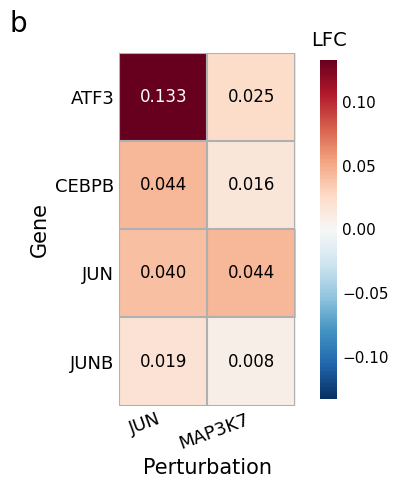

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Convert long-format results to an LFC matrix
gene_order = ["ATF3", "CEBPB", "JUN", "JUNB"]
perturbation_order = ["JUN", "MAP3K7"]

lfc_matrix = (
    df_long
    .pivot(
        index="gene",
        columns="perturbation",
        values="LFC_model",
    )
    .reindex(
        index=gene_order,
        columns=perturbation_order,
    )
)

# Symmetric color scale centered at zero
vmax = np.nanmax(np.abs(lfc_matrix.values))
norm = TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0,
    vmax=vmax,
)

fig, ax = plt.subplots(figsize=(4.2, 5.0))

im = ax.imshow(
    lfc_matrix.values,
    cmap="RdBu_r",
    norm=norm,
    aspect="equal",
)

# Axis labels
ax.set_xticks(np.arange(lfc_matrix.shape[1]))
ax.set_xticklabels(
    lfc_matrix.columns,
    rotation=20,
    ha="right",
    fontsize=13,
)

ax.set_yticks(np.arange(lfc_matrix.shape[0]))
ax.set_yticklabels(
    lfc_matrix.index,
    fontsize=13,
)

ax.set_xlabel("Perturbation", fontsize=15)
ax.set_ylabel("Gene", fontsize=15)

# White borders between cells
ax.set_xticks(
    np.arange(-0.5, lfc_matrix.shape[1], 1),
    minor=True,
)
ax.set_yticks(
    np.arange(-0.5, lfc_matrix.shape[0], 1),
    minor=True,
)

ax.grid(
    which="minor",
    linewidth=1.5,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

ax.tick_params(
    axis="both",
    which="major",
    length=0,
)

# Annotate LFC values
for i in range(lfc_matrix.shape[0]):
    for j in range(lfc_matrix.shape[1]):
        value = lfc_matrix.iloc[i, j]

        text_color = (
            "white"
            if abs(value) > vmax * 0.55
            else "black"
        )

        ax.text(
            j,
            i,
            f"{value:.3f}",
            ha="center",
            va="center",
            fontsize=12,
            color=text_color,
        )

# Remove outer spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.055,
    pad=0.08,
)

cbar.ax.set_title(
    "LFC",
    fontsize=14,
    pad=10,
)

cbar.ax.tick_params(
    labelsize=11,
    length=0,
)

cbar.outline.set_visible(False)

# Optional panel label
ax.text(
    -0.62,
    1.06,
    "b",
    transform=ax.transAxes,
    fontsize=20,
)

plt.tight_layout()
plt.show()